# SIT720 Task 8.1D: Sydney housing prices

This project compares Parramatta, Blacktown and Mosman using 119 publicly advertised sold properties. The aim is to estimate sale price and understand where a simple model fails.

The data were transcribed from public listing pages, with source URLs retained for checking. The dataset and code are available at https://github.com/iamalexthomas/sit720-sydney-housing. The ten personal estimates were recorded after sale prices and reference estimates were disclosed; Part 5 explains how this affects their interpretation.

Run all cells from the project folder. The CSV is included, so running this notebook does not download changing listing pages. See `README.md` for setup. The modelling choices and expectations are explained below.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from stable_knn import StableKNNRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

SEED = 42
ROOT = Path.cwd()
if not (ROOT / "data/housing_sales.csv").exists():
    ROOT = ROOT / "submission"
for folder in ["results", "figures", "model"]:
    (ROOT / folder).mkdir(exist_ok=True)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## Part 1 - Problem and data

The target is sale price in AUD, so this is **regression**, not classification. The three suburbs were confirmed by the student. Parramatta offers an apartment-focused option, Blacktown offers a mix of units and houses, and Mosman provides a much higher-price market. These are possible buying choices with different budgets, rather than a claim that every property is affordable.

The data includes address, suburb, property type, bedrooms, bathrooms, parking, advertised area, sale date, price and a source URL. Unit and apartment labels are combined. A missing parking count is unknown, not zero. The displayed area may be land, floor or entire-block area; it is kept for checking but excluded from modelling. For example, one Blacktown apartment advertises 3,733 square metres.

Listings with withheld prices are excluded. Retirement living is excluded because its ownership and fee arrangements are different. We supplement Mosman apartments with a house-results page to include that market. This is a convenience sample, not a representative random sample. Dates vary by suburb, and duplicates or stale listing information are possible. The collection log explains these limitations.

In [2]:
data = pd.read_csv(ROOT / "data/housing_sales.csv")
data["sale_date"] = pd.to_datetime(data["sale_date"])
assert len(data) >= 100
assert data.groupby("suburb").size().min() >= 30
assert not data.duplicated(["address", "suburb", "sale_date"]).any()
assert data["property_id"].is_unique
assert data["sale_price_aud"].notna().all()
assert (data["sale_price_aud"] > 0).all()
assert (data["sale_date"] <= pd.Timestamp("2026-09-16")).all()
display(data.groupby("suburb").size().rename("Properties").to_frame())
display(data.isna().sum().rename("Missing values").to_frame())
display(data.head(5))

,Properties
suburb,
Blacktown,43
Mosman,39
Parramatta,37


,Missing values
property_id,0
address,0
suburb,0
sale_price_aud,0
property_type,0
bedrooms,0
bathrooms,0
parking,15
advertised_area_m2,65
sale_date,0


,property_id,address,suburb,sale_price_aud,property_type,bedrooms,bathrooms,parking,advertised_area_m2,sale_date,comparison_id,source_url,accessed_date
0,P001,1404/1-3 Valentine Avenue,Parramatta,320000,Apartment,1,1,NaN,NaN,2026-09-11,NaN,https://www.domain.com.au/sold-listings/parram...,2026-09-16
1,P002,33/68 Great Western Highway,Parramatta,520000,Apartment,2,1,1.0,NaN,2026-09-11,NaN,https://www.domain.com.au/sold-listings/parram...,2026-09-16
2,P003,505/23 Hassall Street,Parramatta,660000,Apartment,2,2,1.0,NaN,2026-09-09,NaN,https://www.domain.com.au/sold-listings/parram...,2026-09-16
3,P004,89/459-463 Church Street,Parramatta,580000,Apartment,2,2,1.0,NaN,2026-09-04,NaN,https://www.domain.com.au/sold-listings/parram...,2026-09-16
4,P005,8/64-66 Great Western Highway,Parramatta,425000,Apartment,1,1,1.0,NaN,2026-09-04,NaN,https://www.domain.com.au/sold-listings/parram...,2026-09-16


## Hold out the test properties first

The ten comparison cases were chosen before their prices were revealed to the LLM. Keep all ten in the test set, then add 14 random cases stratified by suburb. This leaves 95 development cases and 24 test cases. The ten chosen cases are a convenience sample, so this test is not purely random. No test price is used to choose the algorithm, settings, scaling or imputation.

A random split can place different units from one building in both sets. It also mixes sale periods. Therefore, it measures performance for this collected sample, not reliable future forecasting. A future project should use building-grouped and forward-in-time evaluation.

In [3]:
comparison_mask = data["comparison_id"].notna()
other = data.loc[~comparison_mask]
train_ids, extra_test_ids = train_test_split(other.index, test_size=14, random_state=SEED,
                                           stratify=other["suburb"])
test_ids = list(data.index[comparison_mask]) + list(extra_test_ids)
train = data.loc[train_ids].copy()
test = data.loc[test_ids].copy()
assert set(train.index).isdisjoint(test.index)
assert len(train) + len(test) == len(data)
split = data[["property_id", "comparison_id"]].copy()
split["split"] = np.where(data.index.isin(train.index), "development", "test")
split.to_csv(ROOT / "data/split.csv", index=False)
print("Development:", len(train), "Test:", len(test))
display(pd.crosstab(data["suburb"], split["split"]))

Development: 95 Test: 24


split,development,test
suburb,,
Blacktown,34,9
Mosman,30,9
Parramatta,31,6


## Part 2 - Understanding the data

The plots below use development data only. Before creating new variables, my expected strongest predictors are **suburb**, **property type** and **bedrooms**. Suburb represents different markets, property type separates houses from apartments, and bedrooms give a rough indication of accommodation. Area might help if it were recorded consistently.

I keep expensive sales rather than deleting them just because they are unusual. A real expensive property is exactly the kind of example that can reveal a model's weakness.

,count,min,median,mean,max
suburb,,,,,
Blacktown,34,375000,854000.0,843882.0,1600000
Mosman,30,700000,2152500.0,3266183.0,11550000
Parramatta,31,320000,572000.0,577613.0,805000


property_type,Apartment,House,Townhouse
suburb,,,
Blacktown,13,17,4
Mosman,17,12,1
Parramatta,31,0,0


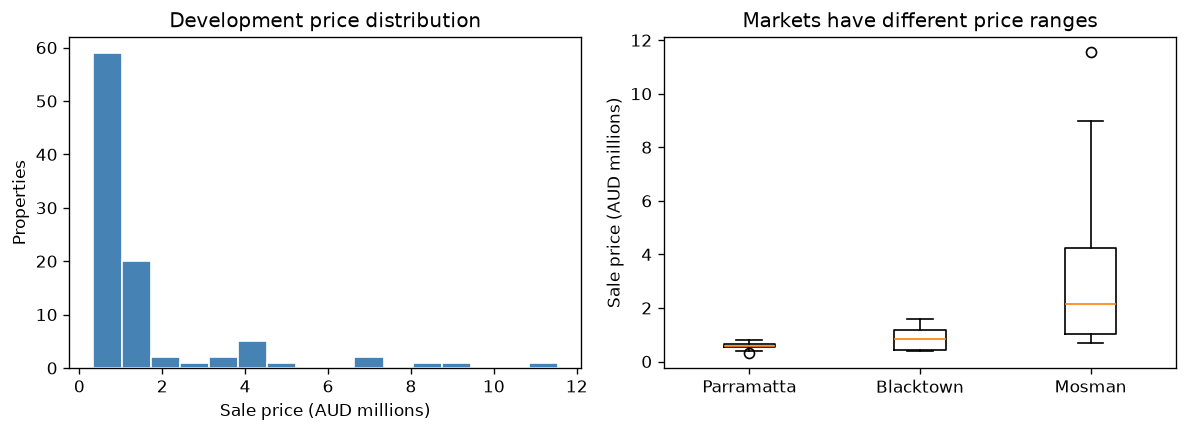

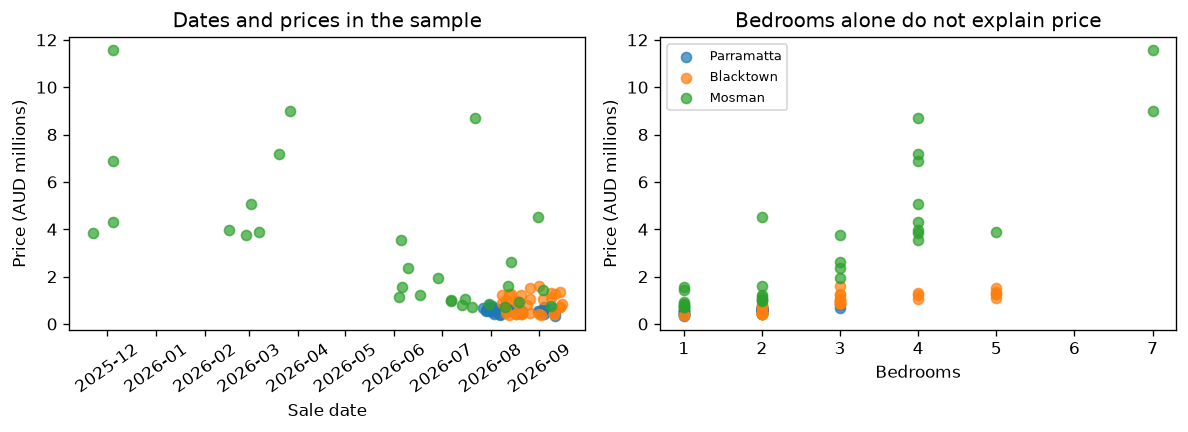

count     median
suburb     month                    
Blacktown  2026-08     21   880000.0
           2026-09     13   828000.0
Mosman     2025-11      1  3850000.0
           2025-12      3  6900000.0
           2026-02      2  3870000.0
           2026-03      4  6136500.0
           2026-06      6  1747500.0
           2026-07      7   990000.0
           2026-08      5  1600000.0
           2026-09      2  1100000.0
Parramatta 2026-07      7   626000.0
           2026-08     16   578500.0
           2026-09      8   545000.0

Monthly medians mix property types and often use very few sales. They do not establish market growth.


,property_id,suburb,property_type,sale_price_aud
99,M020,Mosman,Townhouse,2380000
114,M035,Mosman,House,3990000
90,M011,Mosman,House,8700000
113,M034,Mosman,House,3750000
118,M039,Mosman,House,3850000
85,M006,Mosman,Apartment,2600000
101,M022,Mosman,House,3550000
117,M038,Mosman,House,4320000
82,M003,Mosman,Apartment,4500000
110,M031,Mosman,House,3900000


In [4]:
summary = train.groupby("suburb")["sale_price_aud"].agg(["count", "min", "median", "mean", "max"])
summary.to_csv(ROOT / "results/suburb_summary.csv")
display(summary.round(0))
display(pd.crosstab(train["suburb"], train["property_type"]))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
axes[0].hist(train["sale_price_aud"] / 1e6, bins=16, color="steelblue", edgecolor="white")
axes[0].set(xlabel="Sale price (AUD millions)", ylabel="Properties", title="Development price distribution")
suburbs = ["Parramatta", "Blacktown", "Mosman"]
axes[1].boxplot([train.loc[train.suburb == s, "sale_price_aud"] / 1e6 for s in suburbs], tick_labels=suburbs)
axes[1].set(ylabel="Sale price (AUD millions)", title="Markets have different price ranges")
fig.tight_layout(); fig.savefig(ROOT / "figures/price_distribution.png"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
for suburb in suburbs:
    part = train[train.suburb == suburb]
    axes[0].scatter(part.sale_date, part.sale_price_aud / 1e6, label=suburb, alpha=0.7)
    axes[1].scatter(part.bedrooms, part.sale_price_aud / 1e6, label=suburb, alpha=0.7)
axes[0].set(xlabel="Sale date", ylabel="Price (AUD millions)", title="Dates and prices in the sample")
axes[0].tick_params(axis="x", rotation=35)
axes[1].set(xlabel="Bedrooms", ylabel="Price (AUD millions)", title="Bedrooms alone do not explain price")
axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(ROOT / "figures/time_and_bedrooms.png"); plt.show()
monthly = train.assign(month=train.sale_date.dt.to_period("M").astype(str)).groupby(["suburb", "month"])["sale_price_aud"].agg(["count", "median"])
monthly.to_csv(ROOT / "results/monthly_summary.csv")
display(monthly)
print("Monthly medians mix property types and often use very few sales. They do not establish market growth.")
q1, q3 = train.sale_price_aud.quantile([0.25, 0.75])
outliers = train[train.sale_price_aud > q3 + 1.5 * (q3-q1)]
display(outliers[["property_id", "suburb", "property_type", "sale_price_aud"]])

### What the plots show
Development median prices are $572,000 in Parramatta, $854,000 in Blacktown and $2,152,500 in Mosman. Prices are right-skewed: a few expensive Mosman houses stretch the distribution. These are sample medians, not official suburb medians. The bedroom scatter overlaps substantially, so rooms alone cannot explain price. Older observations are mainly Mosman houses; the apparent fall over time cannot be read as a market fall. The unusual advertised area values are excluded, while genuine expensive prices remain.

### Simple feature engineering and preprocessing

I add a month index relative to January 2025, and bathrooms per bedroom. For a studio I divide by one to avoid dividing by zero. These use no sale prices. The ratio describes accommodation, while the month index allows a possible time effect. However, the time variable may also learn the sampling pattern because older sales are mostly Mosman houses.

Inside each training fold, missing numeric values use that fold's median, numeric features are standardised, and suburb/type use one-hot encoding. Scaling matters for KNN because it calculates distances. Trees do not need scaling, but the same preprocessing is harmless and keeps this example simple. Address and source information are identifiers, not inputs. Sale method is not used because it may only be known after the sale.

In [5]:
def make_features(frame):
    features = frame[["suburb", "property_type", "bedrooms", "bathrooms", "parking"]].copy()
    dates = pd.to_datetime(frame["sale_date"])
    features["sale_month"] = (dates.dt.year - 2025) * 12 + dates.dt.month - 1
    features["bathrooms_per_bedroom"] = features["bathrooms"] / features["bedrooms"].clip(lower=1)
    return features

X_train, X_test = make_features(train), make_features(test)
y_train, y_test = train["sale_price_aud"], test["sale_price_aud"]
numeric = ["bedrooms", "bathrooms", "parking", "sale_month", "bathrooms_per_bedroom"]
categorical = ["suburb", "property_type"]
def make_pipeline(model):
    number_steps = Pipeline([("imputer", SimpleImputer(strategy="median")),
                             ("scaler", StandardScaler())])
    preprocessing = ColumnTransformer([
        ("numbers", number_steps, numeric),
        ("categories", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical)
    ])
    return Pipeline([("preprocess", preprocessing), ("model", model)])
display(X_train.head())

,suburb,property_type,bedrooms,bathrooms,parking,sale_month,bathrooms_per_bedroom
0,Parramatta,Apartment,1,1,NaN,20,1.000000
96,Mosman,Apartment,3,2,2.0,17,0.666667
3,Parramatta,Apartment,2,2,1.0,20,1.000000
86,Mosman,Apartment,2,1,1.0,19,0.500000
45,Blacktown,House,5,2,2.0,20,0.400000


## Part 3 - Models and expectations, before fitting

1. **KNN regression:** predicts from similar training examples. It is easy to understand, but distance can be misleading and a small k can overfit. Larger k gives smoother predictions and can underfit unusual properties.
2. **Decision tree regression:** splits properties into groups and predicts a group's mean price. It captures non-linear patterns and is readable, but a deep tree can memorise a small sample. Depth and minimum leaf size control this.
3. **Random forest regression:** averages 200 trees fitted to bootstrap samples with random feature subsets. I expect it to perform best because averaging reduces the instability of one tree. It is less easy to explain and cannot extrapolate beyond the price range of its training examples.

Some records have equal distances. A small helper breaks these ties by training-row order after rounding squared distances to 12 decimal places. This makes Python and browser predictions agree. It was added to fix deployment consistency, not selected to improve test performance.

These connect to Weeks 8 and 9: distance-based prediction, CART regression, the bias-variance trade-off, bagging and random feature selection. The classification examples in the notes use accuracy; here I use regression metrics. MAE is average absolute dollar error. RMSE gives more weight to large errors. R-squared compares squared error with predicting the evaluation-set mean and can be negative.

Five-fold CV is used on development data only. The small setting search is deliberately simple. Its best CV score is mildly optimistic because it also selected the setting; the untouched test set is the final check.

In [6]:
folds = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", "r2": "r2"}
candidates = {
    "KNN": (StableKNNRegressor(), {"model__n_neighbors": [3, 5, 9]}),
    "Decision tree": (DecisionTreeRegressor(random_state=SEED, min_samples_leaf=3),
                      {"model__max_depth": [2, 4, None]}),
    "Random forest": (RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                            max_features=0.8, random_state=SEED),
                      {"model__max_depth": [4, None]})
}
searches, cv_rows, setting_rows = {}, [], []
for name, (estimator, settings) in candidates.items():
    search = GridSearchCV(make_pipeline(estimator), settings, scoring=scoring, refit="mae",
                          cv=folds, return_train_score=True, n_jobs=1)
    search.fit(X_train, y_train)
    searches[name] = search
    results = search.cv_results_
    best = search.best_index_
    cv_rows.append({"model": name, "train_mae": -results["mean_train_mae"][best],
                    "cv_mae": -results["mean_test_mae"][best], "cv_mae_sd": results["std_test_mae"][best],
                    "cv_rmse": -results["mean_test_rmse"][best], "cv_r2": results["mean_test_r2"][best],
                    "settings": str(search.best_params_)})
    for i, params in enumerate(results["params"]):
        setting_rows.append({"model": name, "settings": str(params),
                             "train_mae": -results["mean_train_mae"][i],
                             "cv_mae": -results["mean_test_mae"][i]})
cv_results = pd.DataFrame(cv_rows).sort_values("cv_mae")
cv_results.to_csv(ROOT / "results/cross_validation.csv", index=False)
settings_results = pd.DataFrame(setting_rows)
settings_results.to_csv(ROOT / "results/model_complexity.csv", index=False)
display(cv_results.round(3)); display(settings_results.round(0))
baseline = make_pipeline(DummyRegressor(strategy="median"))
base_cv = cross_validate(baseline, X_train, y_train, cv=folds, scoring=scoring)
print("Median-baseline CV MAE:", round(-base_cv["test_mae"].mean()))
best_name = cv_results.iloc[0]["model"]
best_model = searches[best_name].best_estimator_
print("Selected using CV only:", best_name)

,model,train_mae,cv_mae,cv_mae_sd,cv_rmse,cv_r2,settings
0,KNN,317781.579,437073.684,207484.517,888508.342,0.625,{'model__n_neighbors': 3}
2,Random forest,303296.324,454019.274,156427.676,1006364.603,0.068,{'model__max_depth': None}
1,Decision tree,376493.659,581341.516,161245.414,1311502.347,-5.053,{'model__max_depth': None}


,model,settings,train_mae,cv_mae
0,KNN,{'model__n_neighbors': 3},317782.0,437074.0
1,KNN,{'model__n_neighbors': 5},362296.0,445622.0
2,KNN,{'model__n_neighbors': 9},443659.0,484836.0
3,Decision tree,{'model__max_depth': 2},564410.0,740984.0
4,Decision tree,{'model__max_depth': 4},422154.0,616947.0
5,Decision tree,{'model__max_depth': None},376494.0,581342.0
6,Random forest,{'model__max_depth': 4},325822.0,467451.0
7,Random forest,{'model__max_depth': None},303296.0,454019.0


Median-baseline CV MAE: 977797
Selected using CV only: KNN


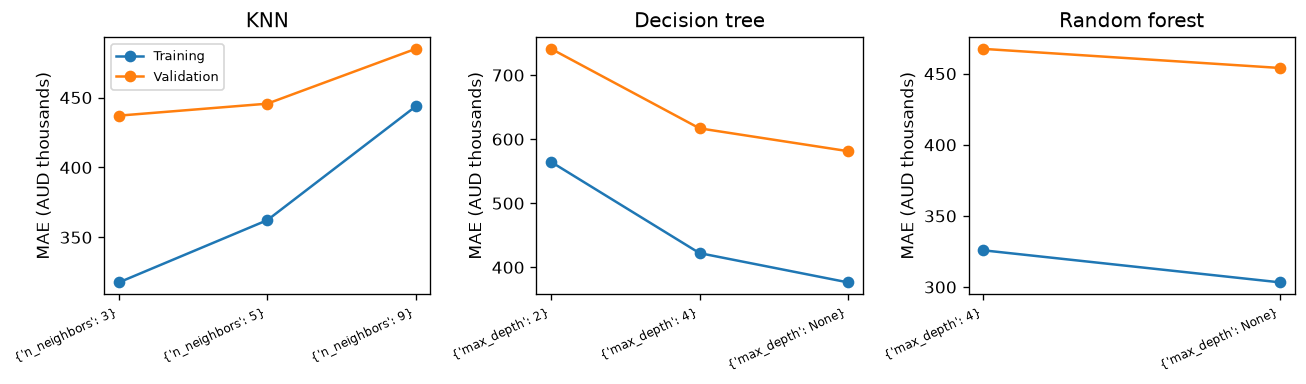

**CV finding:** KNN has the lowest mean MAE ($437,074). Its training MAE is $317,782, so its training-validation gap is $119,292. The CV standard deviation is $207,485; five folds are too few to claim a certain ranking. Check both the gap and absolute errors: low training error with larger validation error suggests overfitting; large errors in both suggest underfitting.

The initial random-forest expectation was not supported.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, name in zip(axes, candidates):
    part = settings_results[settings_results.model == name]
    labels = [s.replace("model__", "") for s in part.settings]
    ax.plot(range(len(part)), part.train_mae / 1000, "o-", label="Training")
    ax.plot(range(len(part)), part.cv_mae / 1000, "o-", label="Validation")
    ax.set_xticks(range(len(part)), labels, rotation=25, ha="right", fontsize=7)
    ax.set(title=name, ylabel="MAE (AUD thousands)")
axes[0].legend(fontsize=8)
fig.tight_layout(); fig.savefig(ROOT / "figures/complexity.png"); plt.show()
winner = cv_results.iloc[0]
display(Markdown(f"**CV finding:** {best_name} has the lowest mean MAE (${winner.cv_mae:,.0f}). "
                 f"Its training MAE is ${winner.train_mae:,.0f}, so its training-validation gap is "
                 f"${winner.cv_mae-winner.train_mae:,.0f}. The CV standard deviation is ${winner.cv_mae_sd:,.0f}; "
                 "five folds are too few to claim a certain ranking. Check both the gap and absolute errors: "
                 "low training error with larger validation error suggests overfitting; large errors in both suggest underfitting."))
print("The initial random-forest expectation was", "supported." if best_name == "Random forest" else "not supported.")

### Final test evaluation

The model has already been selected. The following table reports all three algorithms for transparency, but the test ranking is not used to change the selected algorithm. The deployed model keeps the same development-only fit, so its predictions match this evaluation.

In [8]:
def metric_row(actual, predicted):
    return {"mae": mean_absolute_error(actual, predicted),
            "rmse": np.sqrt(mean_squared_error(actual, predicted)),
            "r2": r2_score(actual, predicted)}

test_rows = []
for name, search in searches.items():
    test_rows.append({"model": name, **metric_row(y_test, search.predict(X_test))})
baseline.fit(X_train, y_train)
test_rows.append({"model": "Median baseline", **metric_row(y_test, baseline.predict(X_test))})
test_metrics = pd.DataFrame(test_rows)
test_metrics.to_csv(ROOT / "results/test_metrics.csv", index=False)
display(test_metrics.round(3))
predictions = best_model.predict(X_test)
test_output = test.copy()
test_output["predicted_price_aud"] = predictions
test_output["signed_error_aud"] = predictions - y_test

,model,mae,rmse,r2
0,KNN,1202750.000,3731553.391,0.384
1,Decision tree,1208407.242,3509637.430,0.455
2,Random forest,1202161.226,3593520.554,0.429
3,Median baseline,2228000.000,5191548.396,-0.193


,suburb,n,mae,rmse,r2,mape_percent
0,Blacktown,9,504388.89,1061341.21,-3.36,34.83
1,Mosman,9,2636092.59,5999542.70,0.15,25.21
2,Parramatta,6,100277.78,128554.43,0.40,22.33


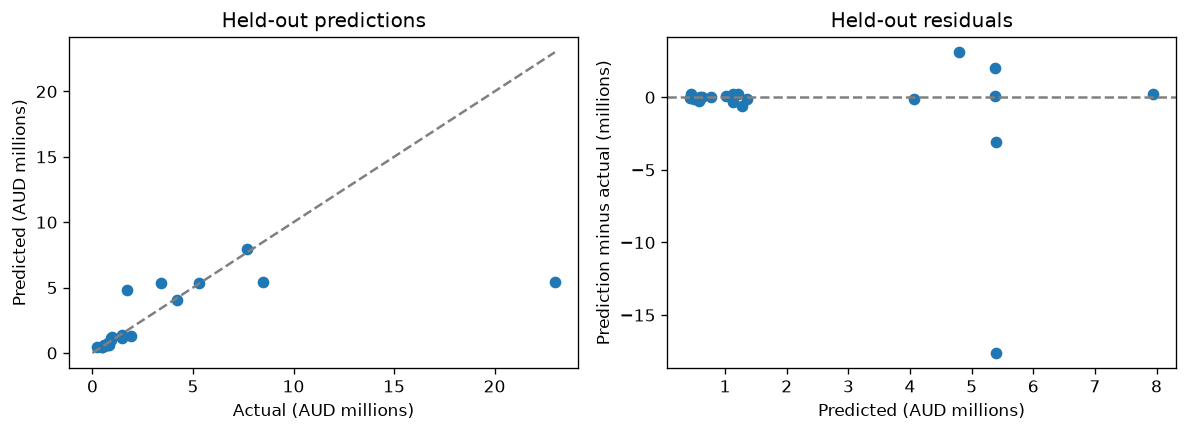

In [9]:
test_output["absolute_error_aud"] = abs(test_output["signed_error_aud"])
test_output["absolute_percentage_error"] = 100 * test_output.absolute_error_aud / test_output.sale_price_aud
test_output.to_csv(ROOT / "results/test_predictions.csv", index=False)
subgroup_rows = []
for suburb, group in test_output.groupby("suburb"):
    subgroup_rows.append({"suburb": suburb, "n": len(group),
                          **metric_row(group.sale_price_aud, group.predicted_price_aud),
                          "mape_percent": group.absolute_percentage_error.mean()})
subgroup_metrics = pd.DataFrame(subgroup_rows)
subgroup_metrics.to_csv(ROOT / "results/subgroup_metrics.csv", index=False)
display(subgroup_metrics.round(2))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
axes[0].scatter(y_test / 1e6, predictions / 1e6)
limit = max(y_test.max(), predictions.max()) / 1e6
axes[0].plot([0, limit], [0, limit], "--", color="grey")
axes[0].set(xlabel="Actual (AUD millions)", ylabel="Predicted (AUD millions)", title="Held-out predictions")
axes[1].scatter(predictions / 1e6, (predictions-y_test) / 1e6)
axes[1].axhline(0, linestyle="--", color="grey")
axes[1].set(xlabel="Predicted (AUD millions)", ylabel="Prediction minus actual (millions)", title="Held-out residuals")
fig.tight_layout(); fig.savefig(ROOT / "figures/test_errors.png"); plt.show()

### Checking the feature expectations

Permutation importance shuffles one column and measures the increase in MAE. I compute it on each validation fold, using the CV-selected settings, then average. This is exploratory because those settings were selected using the same folds. Correlated inputs can share importance; a negative value means shuffling happened to improve the score. This is predictive association, not proof of a cause.

,feature,mae_increase,fold_sd
0,suburb,200616.0,76592.0
5,sale_month,175816.0,111989.0
3,bathrooms,151983.0,57903.0
1,property_type,85051.0,38308.0
4,parking,81547.0,39303.0
2,bedrooms,64545.0,54601.0
6,bathrooms_per_bedroom,40747.0,42467.0


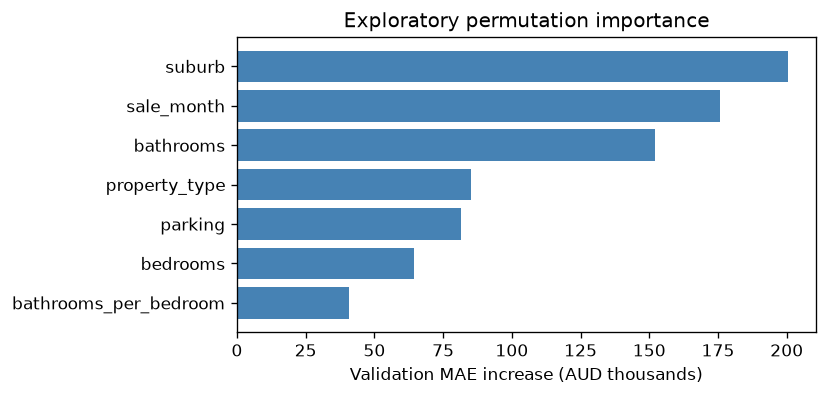

In [10]:
from sklearn.base import clone
importance_rows = []
for fold_number, (fit_rows, valid_rows) in enumerate(folds.split(X_train), start=1):
    fold_model = clone(best_model).fit(X_train.iloc[fit_rows], y_train.iloc[fit_rows])
    importance = permutation_importance(fold_model, X_train.iloc[valid_rows], y_train.iloc[valid_rows],
                                         scoring="neg_mean_absolute_error", n_repeats=10, random_state=SEED)
    importance_rows.append(importance.importances_mean)
importance_table = pd.DataFrame({"feature": X_train.columns,
                                 "mae_increase": np.mean(importance_rows, axis=0),
                                 "fold_sd": np.std(importance_rows, axis=0)}).sort_values("mae_increase", ascending=False)
importance_table.to_csv(ROOT / "results/feature_importance.csv", index=False)
display(importance_table.round(0))
fig, ax = plt.subplots(figsize=(7, 3.4))
part = importance_table.sort_values("mae_increase")
ax.barh(part.feature, part.mae_increase / 1000, color="steelblue")
ax.set(xlabel="Validation MAE increase (AUD thousands)", title="Exploratory permutation importance")
fig.tight_layout(); fig.savefig(ROOT / "figures/importance.png"); plt.show()

### What the model results mean
KNN with three neighbours has the lowest mean validation MAE ($437,074), followed by random forest ($454,019) and the decision tree ($581,342). The $16,946 KNN advantage over forest is much smaller than their fold standard deviations, so the ranking is uncertain. My initial expectation that forest would win was not supported by this score.

Increasing KNN to nine neighbours raises training and validation errors, suggesting too much smoothing. Deeper trees reduce both errors in the tested range, but a training-validation gap remains. It would be wrong to claim that extra depth always causes overfitting. CV R-squared is the mean of five fold scores, and small, different fold price variances make it unstable. The tree's very negative mean R-squared warns of weak folds even though its pooled test R-squared is positive.

On the untouched 24-row test, selected KNN MAE is $1,202,750, RMSE $3,731,553 and R-squared 0.384. The median baseline MAE is $2,228,000. Forest has a slightly smaller test MAE and the tree has smaller RMSE, but changing the chosen model based on these would use the test set for selection. CV performance was also used to choose settings, so it is mildly optimistic.

Validation permutation importance ranks suburb first, then sale month and bathrooms. My original top-three guess is only partly supported: suburb leads, while type and bedrooms rank lower. Correlated features share importance, and month may mainly identify how the data were collected.

## Part 4 - The five largest prediction errors

Rank errors on held-out properties only. A positive signed error is an overestimate and a negative error is an underestimate. The report investigates each of these five records using the listing. Possible missing factors are discussed as possibilities unless supported by a source.

In [11]:
failures = test_output.nlargest(5, "absolute_error_aud")
failures.to_csv(ROOT / "results/five_largest_errors.csv", index=False)
display(failures[["property_id", "address", "suburb", "property_type", "bedrooms", "bathrooms", "parking",
                  "sale_price_aud", "predicted_price_aud", "signed_error_aud", "absolute_percentage_error"]].round(1))
print("Training target range:", f"${y_train.min():,.0f} to ${y_train.max():,.0f}")
print("Test errors are retained, including unusual high-price properties. They are not removed to improve scores.")

,property_id,address,suburb,property_type,bedrooms,bathrooms,parking,sale_price_aud,predicted_price_aud,signed_error_aud,absolute_percentage_error
106,M027,17 Morella Road,Mosman,House,4,3,2.0,23000000,5391000.0,-17609000.0,76.6
108,M029,10 Cyprian Street,Mosman,House,4,3,2.0,8500000,5391000.0,-3109000.0,36.6
78,B042,53 - 53A Pelleas Street,Blacktown,House,7,4,2.0,1700000,4800000.0,3100000.0,182.4
103,M024,96 Glover Street,Mosman,House,4,3,2.0,3390000,5383333.3,1993333.3,58.8
57,B021,13 Lancaster Street,Blacktown,House,7,4,6.0,1900000,1278333.3,-621666.7,32.7


Training target range: $320,000 to $11,550,000
Test errors are retained, including unusual high-price properties. They are not removed to improve scores.


In [12]:
if best_name == "KNN":
    fitted_knn = best_model.named_steps["model"]
    failure_features = best_model.named_steps["preprocess"].transform(make_features(failures))
    squared = np.sum((failure_features[:, None, :] - fitted_knn._fit_X[None, :, :]) ** 2, axis=2)
    positions = np.argsort(np.round(squared, 12), axis=1, kind="stable")[:, :fitted_knn.n_neighbors]
    distances = np.sqrt(np.take_along_axis(squared, positions, axis=1))
    neighbour_rows = []
    for case, distance_row, position_row in zip(failures.itertuples(), distances, positions):
        for distance, position in zip(distance_row, position_row):
            neighbour = train.iloc[position]
            neighbour_rows.append({"test_property": case.property_id, "neighbour_id": neighbour.property_id,
                                   "suburb": neighbour.suburb, "price": neighbour.sale_price_aud,
                                   "distance": distance})
    neighbour_table = pd.DataFrame(neighbour_rows)
    neighbour_table.to_csv(ROOT / "results/failure_neighbours.csv", index=False)
    display(neighbour_table.round(3))

,test_property,neighbour_id,suburb,price,distance
0,M027,M031,Mosman,3900000,0.953
1,M027,M033,Mosman,5075000,1.045
2,M027,M030,Mosman,7198000,1.045
3,M029,M031,Mosman,3900000,0.953
4,M029,M033,Mosman,5075000,1.045
5,M029,M030,Mosman,7198000,1.045
6,B042,B018,Blacktown,1500000,2.122
7,B042,M028,Mosman,9000000,2.747
8,B042,M031,Mosman,3900000,3.101
9,M024,M011,Mosman,8700000,0.456


## What went wrong in the five largest test errors?

1. **17 Morella Road, Mosman (M027):** actual $23,000,000; predicted $5,391,000; under by $17,609,000 (76.6%). The sold listing describes architect-designed luxury, harbour views and direct Chowder Bay access. None is encoded. Its target exceeds the maximum training price ($11.55 million), and averaging neighbours cannot reach it. The sold card lists three bathrooms but Domain's current profile lists four; that inconsistency is flagged rather than silently changed after testing. Sources: https://www.realestate.com.au/sold/property-house-nsw-mosman-149267976 and https://www.domain.com.au/property-profile/17-morella-road-mosman-nsw-2088

2. **10 Cyprian Street, Mosman (M029):** actual $8,500,000; predicted $5,391,000; under by $3,109,000 (36.6%). The listing describes extensive harbour views, a pool and rebuilding potential subject to approval. Its model inputs equal Morella's: four bedrooms, three bathrooms, two parking spaces and March 2026. Consequently both receive exactly the same prediction despite very different prices. Source: https://www.realestate.com.au/sold/property-house-nsw-mosman-150397796

3. **53-53A Pelleas Street, Blacktown (B042):** actual $1,700,000; predicted $4,800,000; over by $3,100,000 (182.4%). The listing describes a renovated dual-living property on a 584-square-metre corner block. Seven bedrooms and four bathrooms are rare in this training sample. Its three chosen neighbours include Mosman homes priced at $9 million and $3.9 million, plus a $1.5 million Blacktown home. This directly shows the distance metric giving inappropriate cross-market comparables. Source: https://www.domain.com.au/53-53a-pelleas-street-blacktown-nsw-2148-2020916590

4. **96 Glover Street, Mosman (M024):** actual $3,390,000; predicted $5,383,333; over by $1,993,333 (58.8%). The listing reports a 379-square-metre block, shared driveway and strata charges of $3,600 per quarter. These are missing from the model, whose neighbours include the $8.7 million Botanic Road sale. These differences plausibly matter, but this dataset cannot prove their separate price effects. Source: https://www.realestate.com.au/sold/property-house-nsw-mosman-150415760

5. **13 Lancaster Street, Blacktown (B021):** actual $1,900,000; predicted $1,278,333; under by $621,667 (32.7%). The listing describes a custom-built, approximately four-year-old house intended for large or multigenerational families. The model has no construction-age or finish-quality features. Its neighbours are three Blacktown houses priced between $1.235 million and $1.34 million, so averaging misses this local premium. Source: https://www.domain.com.au/13-lancaster-street-blacktown-nsw-2148-2021028342

These are source-supported contexts and plausible explanations, not causal findings. All listing pages were consulted for failure analysis after estimates were frozen. Neither their descriptions nor held-out prices were used to revise the selected model. Future improvements include separate location-aware comparables, verified land/floor area, tenure and strata costs, condition, waterfront/view information and grouping multiple dwellings explicitly. Unusual luxury, dual-living and strata-titled houses need particular caution.


## Part 5 - ML, LLM and student estimates

The ten comparison properties remain outside model training. LLM estimates were frozen before their target prices were revealed; the prompt and recording conditions are given below.

The student supplied ten estimates on 18 September 2026. They are copied exactly into `human_estimate_aud` in `data/comparison_blind.csv`; the filename is historical. The student had already seen actual sale prices, ML/LLM results and AI-generated examples, so these estimates are **non-blind**. All three columns refer to the same properties and raw feature fields, but their information conditions differ. The student scores cannot establish independent human forecasting performance.

The LLM had general prior knowledge and earlier market examples. Ten convenience-selected properties and unequal information cannot establish a universal winner.

### LLM estimation procedure

The estimates were recorded on 16 September 2026 using the Codex assistant in the project conversation. The interface did not supply an exact underlying model identifier. The prompt was:

> Estimate a sale price in Australian dollars for each row of comparison_blind.csv using only suburb, property type, bedrooms, bathrooms, parking and sale date. A blank parking count means unknown. Treat bedrooms=0 as a studio. Do not look up the property, use its address or advertised area, inspect its actual price, or use ML predictions. Return one estimate and a short reason for each row.

Prices on the selected source pages were hidden during this step, and previously viewed addresses were excluded. Estimates were saved before targets were revealed and before fitting the models. Earlier market examples were available in the conversation, so this was not a fresh-session experiment; training-data memorisation cannot be ruled out.

Selection used two previously unseen Parramatta records, the first four eligible Blacktown page-3 records, and the first four previously unseen Mosman house records with disclosed prices. This convenience sample contains extra houses and is not a random Sydney benchmark.

`data/illustrative_estimates.csv` retains the earlier assistant-generated examples separately. These were produced after outcomes were available and are not personal forecasts. The later student-supplied values in `human_estimate_aud` do not alter the held-out split or the frozen ML and LLM predictions.


In [13]:
human = pd.read_csv(ROOT / "data/comparison_blind.csv")
llm = pd.read_csv(ROOT / "data/llm_estimates.csv")
assert human.comparison_id.is_unique and llm.comparison_id.is_unique
assert set(human.comparison_id) == set(llm.comparison_id)
comparison = test_output[test_output.comparison_id.notna()].merge(llm, on="comparison_id", validate="one_to_one")
comparison = comparison.merge(human[["comparison_id", "human_estimate_aud"]], on="comparison_id", validate="one_to_one")
comparison = comparison.sort_values("comparison_id")
comparison.to_csv(ROOT / "results/ten_property_comparison.csv", index=False)
display(comparison[["comparison_id", "suburb", "sale_price_aud", "predicted_price_aud",
                    "llm_estimate_aud", "human_estimate_aud"]].round(0))
comparison_scores = []
for label, column in [("ML", "predicted_price_aud"), ("LLM", "llm_estimate_aud"), ("Student (non-blind)", "human_estimate_aud")]:
    values = pd.to_numeric(comparison[column], errors="coerce")
    if values.notna().all() and np.isfinite(values).all() and (values > 0).all():
        comparison_scores.append({"approach": label, **metric_row(comparison.sale_price_aud, values)})
    else:
        print(label + " comparison incomplete: ten positive estimates are required.")
comparison_metrics = pd.DataFrame(comparison_scores)
comparison_metrics.to_csv(ROOT / "results/comparison_metrics.csv", index=False)
display(comparison_metrics.round(3))
print("Student estimates were supplied after price/example disclosure; scores do not establish independent human superiority.")

,comparison_id,suburb,sale_price_aud,predicted_price_aud,llm_estimate_aud,human_estimate_aud
0,C01,Parramatta,250000,443000.0,310000,345000
1,C02,Parramatta,685000,572333.0,810000,785000
2,C03,Blacktown,465000,438000.0,450000,495000
3,C04,Blacktown,900000,1131000.0,1150000,1180000
4,C05,Blacktown,1700000,4800000.0,1750000,1425000
5,C06,Blacktown,590000,499667.0,520000,580000
6,C07,Mosman,3390000,5383333.0,4800000,4650000
7,C08,Mosman,5300000,5383333.0,4700000,5250000
8,C09,Mosman,4200000,4070000.0,5100000,4880000
9,C10,Mosman,23000000,5391000.0,4800000,5350000


,approach,mae,rmse,r2
0,ML,2356966.667,5690310.151,0.242
1,LLM,2168000.000,5783488.999,0.217
2,Student (non-blind),2043000.000,5601330.645,0.265


Student estimates were supplied after price/example disclosure; scores do not establish independent human superiority.


### Earlier illustrative estimates (separate from student estimates)

Before the student supplied their own values, the assistant generated rounded examples at the student's request. These historical **AI-generated illustrative estimates** remain in a separate column. They were made after actual prices were available. Their scores demonstrate arithmetic only; they are not used as student estimates or evidence of human performance.

In [14]:
illustrative = pd.read_csv(ROOT / "data/illustrative_estimates.csv")
comparison = comparison.merge(illustrative, on="comparison_id", validate="one_to_one")
comparison.to_csv(ROOT / "results/ten_property_comparison.csv", index=False)
display(comparison[["comparison_id", "sale_price_aud", "predicted_price_aud", "llm_estimate_aud", "illustrative_estimate_aud"]].round(0))
print("Illustrative-only errors (not human evidence):", metric_row(comparison.sale_price_aud, comparison.illustrative_estimate_aud))

,comparison_id,sale_price_aud,predicted_price_aud,llm_estimate_aud,illustrative_estimate_aud
0,C01,250000,443000.0,310000,300000
1,C02,685000,572333.0,810000,750000
2,C03,465000,438000.0,450000,450000
3,C04,900000,1131000.0,1150000,1100000
4,C05,1700000,4800000.0,1750000,1500000
5,C06,590000,499667.0,520000,550000
6,C07,3390000,5383333.0,4800000,5000000
7,C08,5300000,5383333.0,4700000,5000000
8,C09,4200000,4070000.0,5100000,5000000
9,C10,23000000,5391000.0,4800000,5000000


Illustrative-only errors (not human evidence): {'mae': 2128000.0, 'rmse': np.float64(5721980.863302498), 'r2': 0.23350875985072495}


### Comparison findings

For the ten properties, student MAE is $2,043,000, RMSE is $5,601,331 and R-squared is 0.265. ML MAE is $2,356,967 and RMSE is $5,690,310. LLM MAE is $2,168,000 and RMSE is $5,783,489. The student column therefore has the lowest reported MAE and RMSE, but exposure to actual prices and example estimates prevents a fair forecasting winner claim.

The student column is closest on C02, C06, C07 and C08 (four cases); LLM is closest on C01, C03 and C05 (three); ML is closest on C04, C09 and C10 (three). The student's C06 estimate is only $10,000 away and C08 is $50,000 away. All three miss the $23 million Morella sale badly; the student's absolute error there is $17.65 million.

Between ML and LLM, LLM has lower MAE but ML has lower RMSE. ML provides repeatable predictions but depends on data coverage and its distance rule. LLM estimates can be plausible without reflecting exceptional property details. Human judgement could add inspection and local knowledge, but this non-blind table does not isolate that benefit. A stronger study needs fresh unseen properties and estimates recorded before outcomes and other predictions are shown.

## Part 6 - Export and application

The app uses the same fitted pipeline as the test evaluation. Numeric imputation, scaling, category order and the trained model are exported together. `app.py` provides a small Flask version. `site/dist` contains a browser version for hosting; it performs inference from exported learned parameters rather than making up a formula. Both use the same feature engineering.

This is an educational estimate. It does not replace property inspection, comparable sales or a professional valuation. The sample is small, has strong suburb/type/date imbalance, and lacks condition, views, internal floor area, strata costs and development potential. A suburb can also act as a proxy for historic inequality. Compare errors by suburb and avoid using this prototype for lending or excluding groups of buyers.

The most useful improvements are more sales with consistent land/floor areas, verified dates and prices, building-level grouping, forward-time tests, and a properly blinded human/LLM study. More computing power alone will not fix missing information.

In [15]:
joblib.dump(best_model, ROOT / "model/housing_model.joblib")
metadata = {"selected_model": best_name, "development_n": len(train), "test_n": len(test),
            "total_n": len(data), "seed": SEED, "numeric": numeric, "categorical": categorical,
            "test_metrics": metric_row(y_test, predictions),
            "training_min_date": str(train.sale_date.min().date()),
            "training_max_date": str(train.sale_date.max().date()),
            "training_min_price": int(y_train.min()), "training_max_price": int(y_train.max()),
            "human_complete": bool(human.human_estimate_aud.notna().all()),
            "human_blinded": False}
(ROOT / "results/summary.json").write_text(json.dumps(metadata, indent=2))
print("Saved fitted model and results.")
print("Selected model:", best_name)
print("Run the local application with: python app.py")

Saved fitted model and results.
Selected model: KNN
Run the local application with: python app.py
